In [14]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

import awkward as ak
from coffea.util import load

In [55]:
input = "/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/ggF_vbf_ZZ_ZH_data_parkingHH_vbf_spanet_bkg_rwg_SvB_2023_postBPix/output_GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00_2023_postBPix.coffea"
# input = "/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/ggF_vbf_ZZ_ZH_data_parkingHH_vbf_spanet_bkg_rwg_SvB_2023_postBPix/output_ZZTo4B01j_2023_postBPix.coffea"
o = load(f"{input}")

samples = list(o['columns'].keys())
list(o['columns'].keys())

['GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00']

In [56]:
input_h5 = {
    "HH_ZZ_ZH_QCD": {
        "PRED_FILE": "/pnfs/psi.ch/cms/trivcat/store/user/bevila_t/PostDoc/HH4b/ml_trainings/spanet/ZZ_ZH_HH_QCD_classification_two_tiers_v2/out_HH_ZH_ZZ_DATA_classification_step_2_phaseB_continued_v2/version_0/SM_HH_HZ_ZZ_DATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test_output.h5",
        "CLASS_NAMES"        : ["HH", "QCD", "ZH", "ZZ"],
    }
}

In [57]:
s = samples[0]
subsample = list(o['columns'][s].keys())[0]
regions = list(o['columns'][s][subsample].keys())   
print(f"Regions: {regions}")

Regions: ['4b_control_region', '4b_signal_region', '2b_control_region_postW', '2b_control_region_preW', '2b_signal_region_postW', '2b_signal_region_preW', '4b_region']


In [58]:
o_cat = list(o['columns'][s][subsample]['4b_signal_region']['nominal'].keys())
for c in o_cat:
    print(c)

weight
events_sigma_over_higgs2_reco_mass
events_HT
events_Arctanh_Delta_pairing_probabilities
events_Binned_Arctanh_Delta_pairing_probabilities
events_dR_max
events_sigma_over_higgs1_reco_mass
events_mjjJetTotalSPANetPadded
events_era
events_Delta_pairing_probabilities
events_centralityHiggsLeadingJetTotalSPANetPadded
events_centralityHiggsSubLeadingJetTotalSPANetPadded
events_dR_min
events_detaJetTotalSPANetPadded
events_year
events_Padded_Arctanh_Delta_pairing_probabilities
JetTotalSPANetPadded_N
JetTotalSPANetPadded_phi
JetTotalSPANetPadded_mass
JetTotalSPANetPadded_pt
JetTotalSPANetPadded_eta
HiggsLeading_dR
HiggsLeading_mass
HiggsLeading_phi
HiggsLeading_pt
HiggsLeading_eta
HiggsLeading_helicityCosTheta
HiggsLeading_dEta
HiggsSubLeading_dR
HiggsSubLeading_mass
HiggsSubLeading_phi
HiggsSubLeading_pt
HiggsSubLeading_eta
HiggsSubLeading_helicityCosTheta
HiggsSubLeading_dEta
HH_dR
HH_mass
HH_Costhetastar_CS
HH_phi
HH_pt
HH_dPhi
HH_eta
HH_dEta
JetGoodFromHiggsOrdered_N
JetGoodFromHigg

In [59]:
ev = {}
for s in samples:
    print(f"Sample: {s}")
    r = '4b_region'
    sub_s = list(o['columns'][s].keys())[0]
    ev[s] = {x: o['columns'][s][sub_s][r]['nominal'][x].value for x in o_cat}

Sample: GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00


In [60]:
for field in o_cat:    
    for s in samples:    
        # print(f"{field}: {ev[s][field].shape}")
        if "Jet" in field.split("_")[0] and "_N" not in field:
            if field.rsplit("_", 1)[0] + "_N" in ev[s].keys():
                counts = field.rsplit("_", 1)[0] + "_N"
            elif field.rsplit("_", 2)[0] + "_N" in ev[s].keys():
                counts = field.rsplit("_", 2)[0] + "_N"
            else:
                print(f"no counts found for {field}")
                break
            ev[s][field] = ak.unflatten(ev[s][field], ev[s][counts])
        
for s in samples:     
    ev[s]["events_sig_bkg_dnn_score_total"] = ev[s]["events_sig_bkg_dnn_score_0"] + ev[s]["events_sig_bkg_dnn_score_1"] + ev[s]["events_sig_bkg_dnn_score_2"] + ev[s]["events_sig_bkg_dnn_score_3"]
    print(f"Sample: {s}, events_sig_bkg_dnn_score_total: {ev[s]['events_sig_bkg_dnn_score_total']}")

Sample: GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00, events_sig_bkg_dnn_score_total: [1.0000001  1.         1.0000001  ... 1.         0.99999994 1.        ]


In [61]:
ev[s]["events_sig_bkg_dnn_score_1"]

array([0.07800761, 0.00549494, 0.03420111, ..., 0.00943609, 0.0063041 ,
       0.3635641 ], dtype=float32)

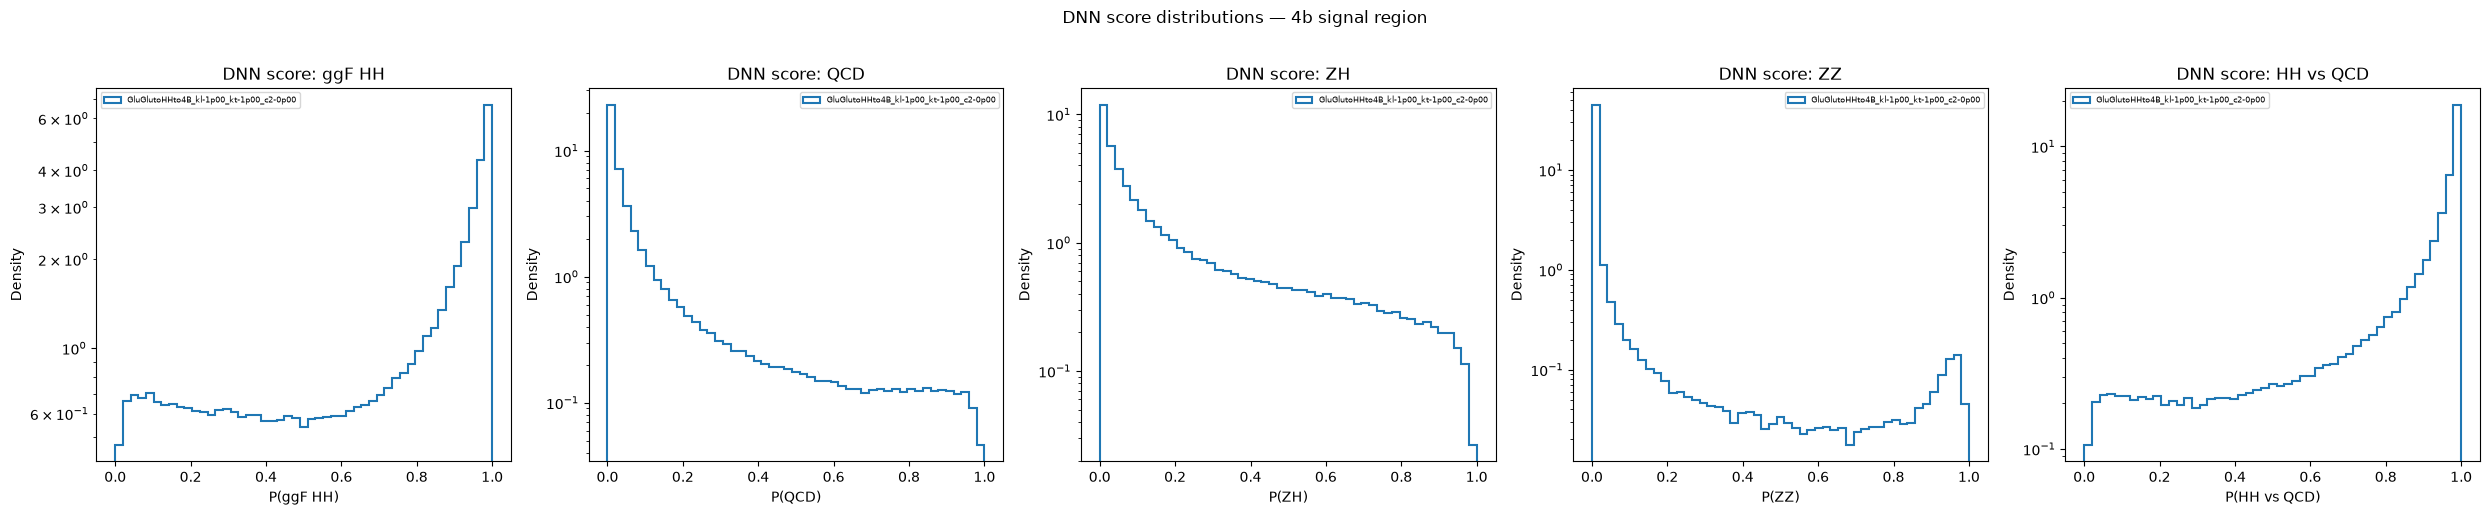

saved dnn_score_distributions_per_sample_log.png


In [62]:
# ── DNN score distributions per sample ───────────────────────────────────────
# Plots each of the 4 DNN output scores (sig_bkg_dnn_score_0..3) overlaid
# across all MC samples + data. Weights are taken from the 'weight' column.
# Toggle LOG = True/False to switch y-axis scale.

LOG = True

# Human-readable labels for the 4 DNN output nodes (adjust if needed)
SCORE_COLS  = [
    "events_sig_bkg_dnn_score_0",
    "events_sig_bkg_dnn_score_1",
    "events_sig_bkg_dnn_score_2",
    "events_sig_bkg_dnn_score_3",
    "events_sig_bkg_dnn_score",
]
SCORE_NAMES = ["ggF HH", "QCD", "ZH", "ZZ", "HH vs QCD"]   # update to match your training

SAMPLE_COLORS = {
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00": "tab:blue",
    "VBFHHto4B_CV_1_C2V_0_C3_1":               "tab:orange",
    "ZH_ZToBB_HToBB":                           "tab:green",
    "ggZH_HToBB_ZToBB":                         "tab:olive",
    "ZZTo4B01j":                                "tab:red",
    "DATA_ParkingHH":                           "black",
}

bins = np.linspace(0, 1, 50)
fig, axes = plt.subplots(1, len(SCORE_COLS), figsize=(5 * len(SCORE_COLS), 5), sharey=False)

for ax, col, name in zip(axes, SCORE_COLS, SCORE_NAMES):
    for s in samples:
        if col not in ev[s]:
            continue
        jet_pt = ev[s]["JetTotalSPANetPadded_pt"]
        scores  = np.asarray(ev[s][col])
        weights = np.asarray(ev[s]["weight"])
        
        # print(len(scores), len(weights), len(jet_pt))
        # print(jet_pt)
        # scores = scores[ak.num(jet_pt[jet_pt > 0]) > 5]
        # weights = weights[ak.num(jet_pt[jet_pt > 0]) > 5]
        # print(len(scores), len(weights), len(jet_pt))
        if s == "ggZH_HToBB_ZToBB": 
            print(weights)
            scores = scores[weights < 10]
            weights = weights[weights < 10]

        color   = SAMPLE_COLORS.get(s, None)
        ls      = "--" if s.startswith("DATA") else "-"
        ax.hist(
            scores,
            bins=bins,
            weights=weights,
            histtype="step",
            linewidth=1.5,
            linestyle=ls,
            color=color,
            label=s,
            density=True,
        )
    ax.set_xlabel(f"P({name})")
    ax.set_ylabel("Density")
    ax.set_title(f"DNN score: {name}")
    ax.legend(fontsize=6)
    if LOG:
        ax.set_yscale("log")

log_tag = "_log" if LOG else ""
fig.suptitle(f"DNN score distributions — 4b signal region", y=1.02)
fig.tight_layout()
fname = f"dnn_score_distributions_per_sample{log_tag}.png"
fig.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {fname}")


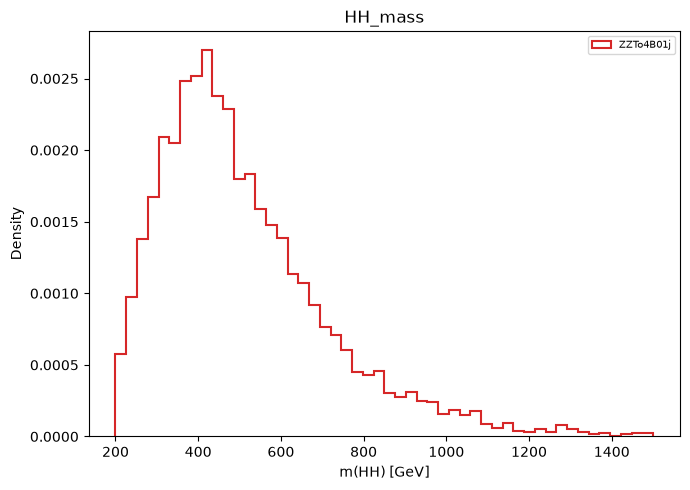

saved input_var_HH_mass.png


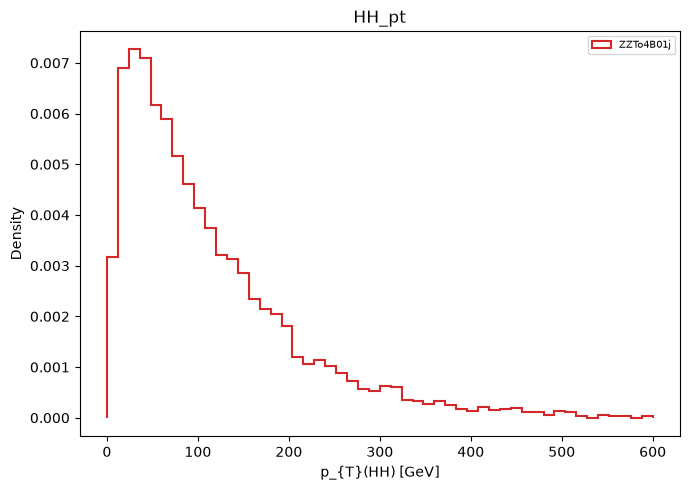

saved input_var_HH_pt.png


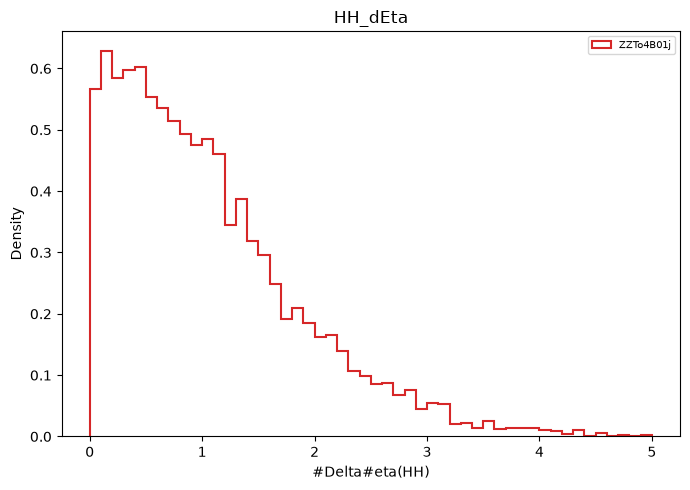

saved input_var_HH_dEta.png


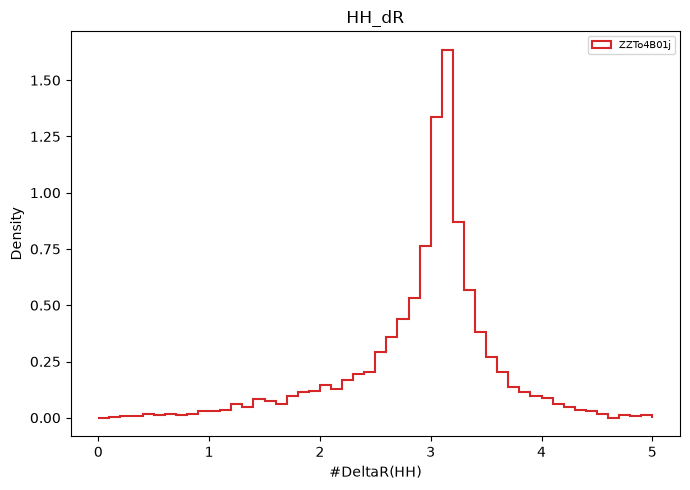

saved input_var_HH_dR.png


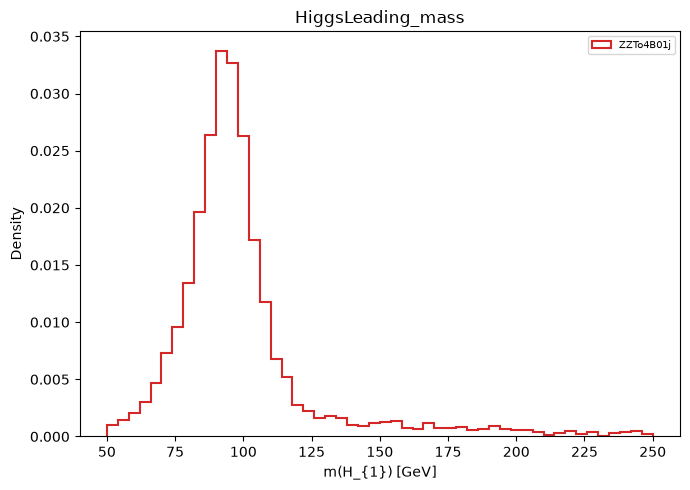

saved input_var_HiggsLeading_mass.png


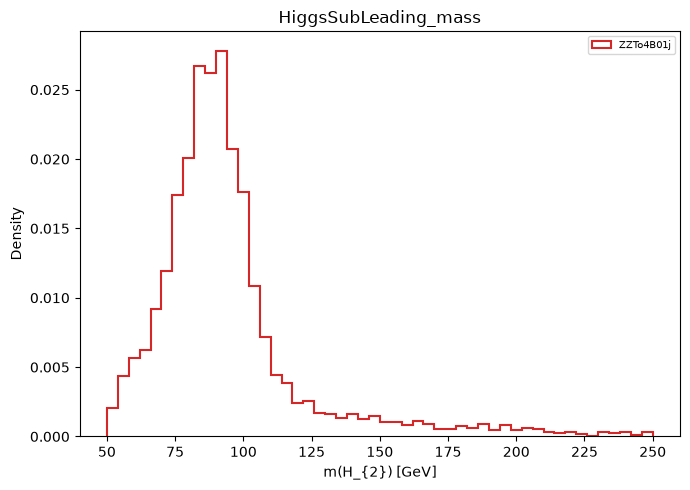

saved input_var_HiggsSubLeading_mass.png


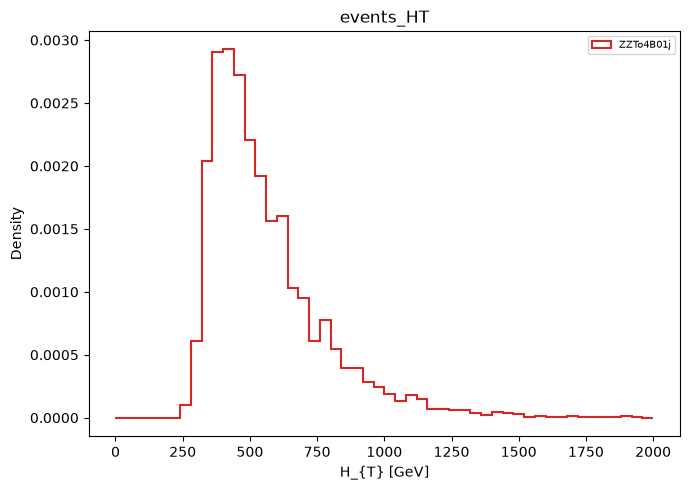

saved input_var_events_HT.png


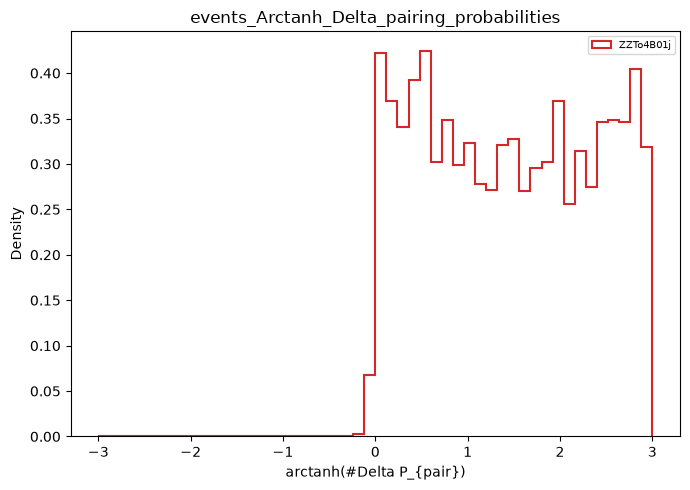

saved input_var_events_Arctanh_Delta_pairing_probabilities.png


In [23]:
# ── Input variable distributions per sample ──────────────────────────────────
# Scalar event-level variables overlaid across all samples.
# Each variable gets its own figure. Jagged arrays are flattened automatically.

LOG_VARS = False

# (column_name, x-label, (xmin, xmax), n_bins)
INPUT_VARS = [
    ("HH_mass",                                "m(HH) [GeV]",          (200, 1500), 50),
    ("HH_pt",                                  "p_{T}(HH) [GeV]",       (0, 600),   50),
    ("HH_dEta",                                "#Delta#eta(HH)",         (0, 5),     50),
    ("HH_dR",                                  "#DeltaR(HH)",            (0, 5),     50),
    ("HiggsLeading_mass",                      "m(H_{1}) [GeV]",        (50, 250),  50),
    ("HiggsSubLeading_mass",                   "m(H_{2}) [GeV]",        (50, 250),  50),
    ("events_HT",                              "H_{T} [GeV]",           (0, 2000),  50),
    ("events_Arctanh_Delta_pairing_probabilities", "arctanh(#Delta P_{pair})", (-3, 3), 50),
]

SAMPLE_COLORS = {
    "GluGlutoHHto4B_kl-1p00_kt-1p00_c2-0p00": "tab:blue",
    "VBFHHto4B_CV_1_C2V_0_C3_1":               "tab:orange",
    "ZH_ZToBB_HToBB":                           "tab:green",
    "ggZH_HToBB_ZToBB":                         "tab:olive",
    "ZZTo4B01j":                                "tab:red",
    "DATA_ParkingHH":                           "black",
}

import awkward as ak
import numpy as np

log_tag = "_log" if LOG_VARS else ""

for col, xlabel, (xmin, xmax), nbins in INPUT_VARS:
    bins = np.linspace(xmin, xmax, nbins + 1)
    fig, ax = plt.subplots(figsize=(7, 5))

    for s in samples:
        if col not in ev[s]:
            print(f"  skipping {s}: column {col!r} not found")
            continue
        vals    = np.asarray(ak.flatten(ev[s][col], axis=None))
        weights = np.asarray(ev[s]["weight"])

        if s == "ggZH_HToBB_ZToBB": 
            print(weights)
            scores = scores[weights < 10]
            weights = weights[weights < 10]

        # if jagged, weights need to be broadcast to match flattened length
        if vals.shape[0] != weights.shape[0]:
            counts = np.asarray(ak.num(ev[s][col], axis=-1)) if ev[s][col].ndim > 1 else None
            if counts is not None:
                weights = np.repeat(weights, counts)

        color = SAMPLE_COLORS.get(s, None)
        ls    = "--" if s.startswith("DATA") else "-"
        ax.hist(
            vals,
            bins=bins,
            weights=weights,
            histtype="step",
            linewidth=1.5,
            linestyle=ls,
            color=color,
            label=s,
            density=True,
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.set_title(col)
    ax.legend(fontsize=7)
    if LOG_VARS:
        ax.set_yscale("log")

    fig.tight_layout()
    fname = f"input_var_{col}{log_tag}.png"
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"saved {fname}")


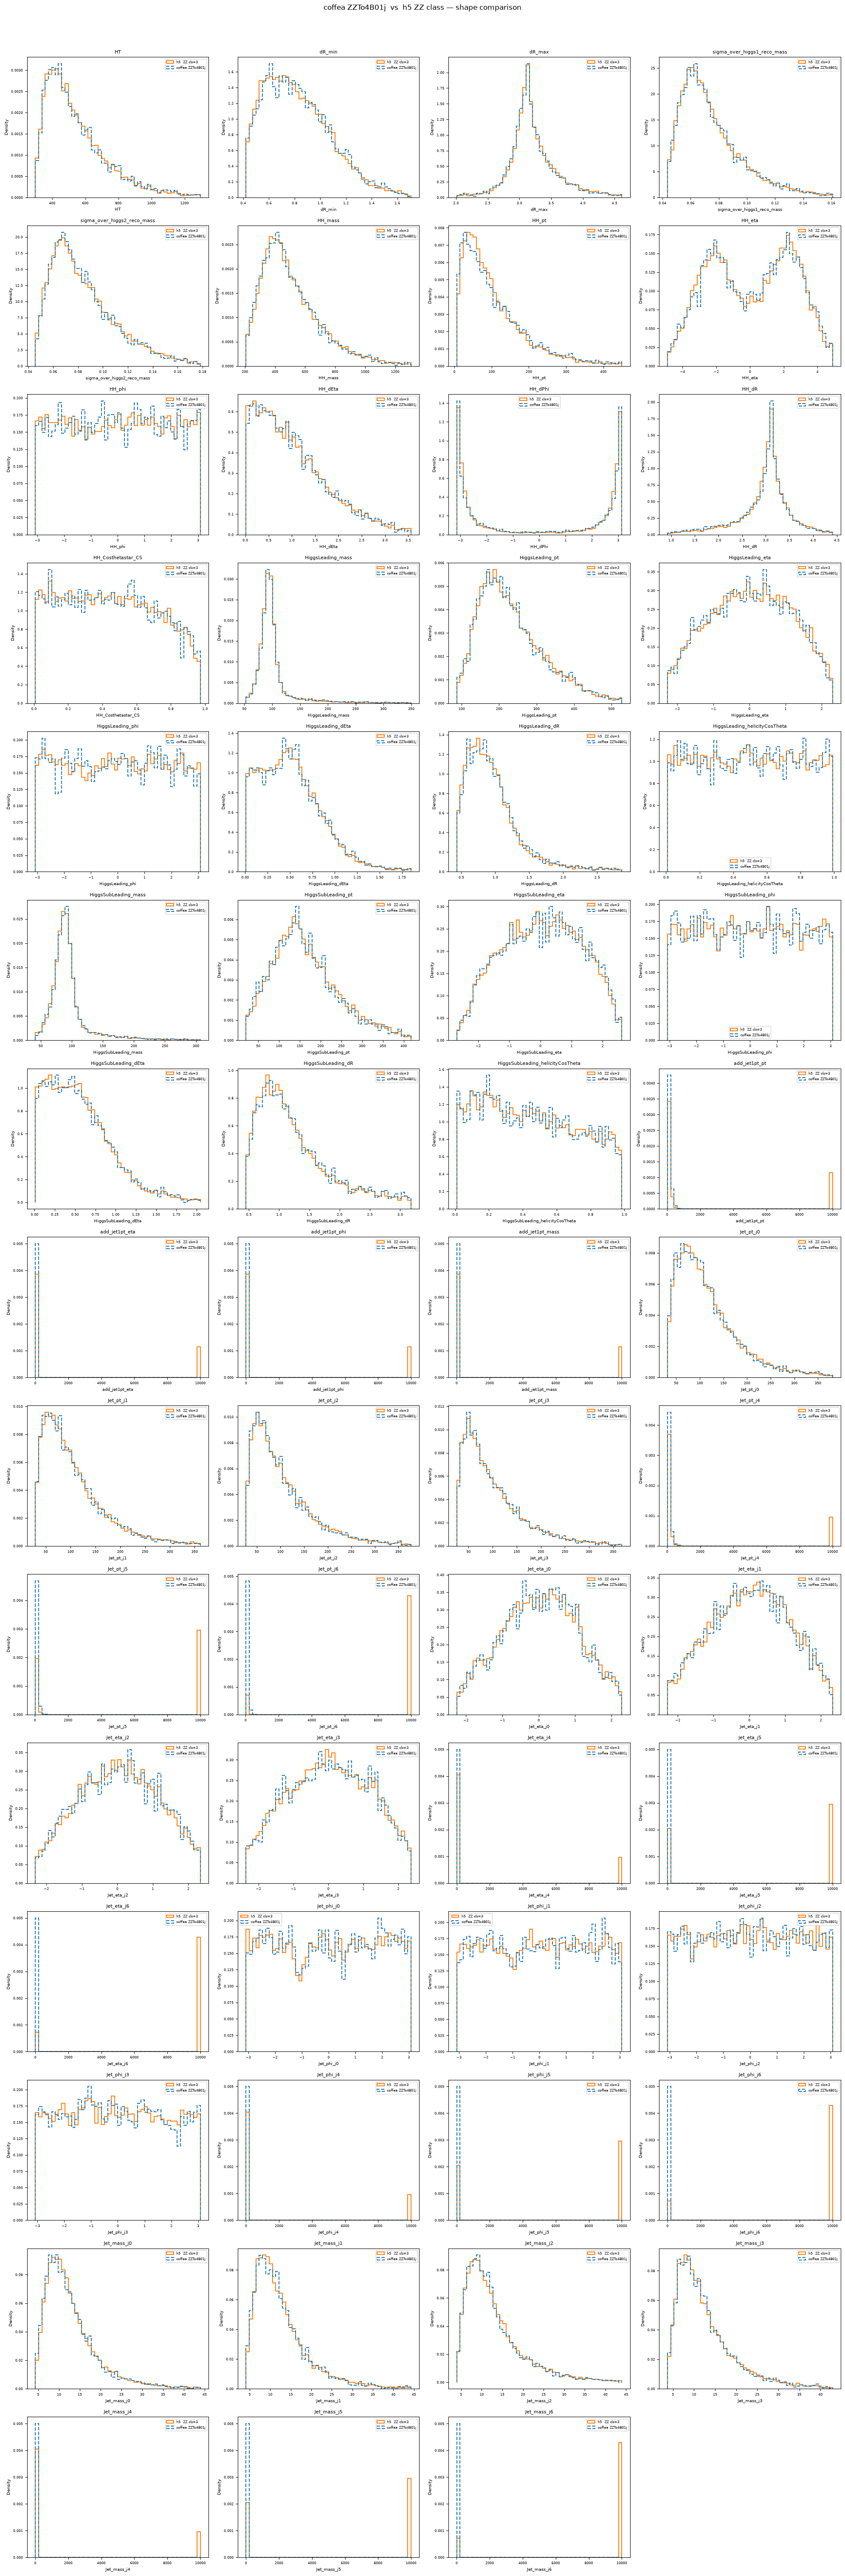

saved coffea_vs_h5_ZZ_comparison.png  (59 variables)


In [24]:
# ── coffea vs h5: variable comparison for ZZ sample ─────────────────────────
# Coffea source : ev[samples[0]]  (ZZTo4B01j loaded in cell 1)
# h5 source     : SM_HH_HZ_ZZ_4bDATA…JetTotalSPANetPadded_test.h5, class 3 = ZZ
#                 CLASS_NAMES = ["HH", "QCD", "ZH", "ZZ"]
#
# For each shared variable one panel is produced. Per-jet variables are split
# by jet index (0–3, i.e. the four Higgs jets). Bin edges are set from
# data percentiles so tails don't dominate the axis.

import h5py, numpy as np, matplotlib.pyplot as plt, awkward as ak, math

H5_FILE   = "/work/bevila_t/PostDoc/HH4b/Output/PocketCoffea/ggF_vbf_data_parkingHH_spanet_bkg_rwg_2023_postBPix/SM_HH_HZ_ZZ_4bDATA_filter_abs_neg_weights_norm_by_sample_JetTotalSPANetPadded_test.h5"
ZZ_CLASS  = 3   # index of ZZ in CLASS_NAMES ["HH","QCD","ZH","ZZ"]
N_BINS    = 50
LOG_COMP  = False
N_JETS    = 7   # jet indices to compare

# ── load h5 ZZ slice ─────────────────────────────────────────────────────────
with h5py.File(H5_FILE) as h:
    mask_zz  = h["CLASSIFICATIONS/EVENT/class"][:] == ZZ_CLASS
    w_h5     = h["WEIGHTS/weight"][:][mask_zz]

    def load_h5(group, field):
        return h[f"INPUTS/{group}/{field}"][:][mask_zz]

    h5 = {
        # Event-level
        "HT"                             : load_h5("Event", "HT"),
        "dR_min"                         : load_h5("Event", "dR_min"),
        "dR_max"                         : load_h5("Event", "dR_max"),
        "sigma_over_higgs1_reco_mass"    : load_h5("Event", "sigma_over_higgs1_reco_mass"),
        "sigma_over_higgs2_reco_mass"    : load_h5("Event", "sigma_over_higgs2_reco_mass"),
        # HH system
        "HH_mass"           : load_h5("HH", "mass"),
        "HH_pt"             : load_h5("HH", "pt"),
        "HH_eta"            : load_h5("HH", "eta"),
        "HH_phi"            : load_h5("HH", "phi"),
        "HH_dEta"           : load_h5("HH", "dEta"),
        "HH_dPhi"           : load_h5("HH", "dPhi"),
        "HH_dR"             : load_h5("HH", "dR"),
        "HH_Costhetastar_CS": load_h5("HH", "Costhetastar_CS"),
        # Leading Higgs
        "HiggsLeading_mass"            : load_h5("HiggsLeading", "mass"),
        "HiggsLeading_pt"              : load_h5("HiggsLeading", "pt"),
        "HiggsLeading_eta"             : load_h5("HiggsLeading", "eta"),
        "HiggsLeading_phi"             : load_h5("HiggsLeading", "phi"),
        "HiggsLeading_dEta"            : load_h5("HiggsLeading", "dEta"),
        "HiggsLeading_dR"              : load_h5("HiggsLeading", "dR"),
        "HiggsLeading_helicityCosTheta": load_h5("HiggsLeading", "helicityCosTheta"),
        # SubLeading Higgs
        "HiggsSubLeading_mass"            : load_h5("HiggsSubLeading", "mass"),
        "HiggsSubLeading_pt"              : load_h5("HiggsSubLeading", "pt"),
        "HiggsSubLeading_eta"             : load_h5("HiggsSubLeading", "eta"),
        "HiggsSubLeading_phi"             : load_h5("HiggsSubLeading", "phi"),
        "HiggsSubLeading_dEta"            : load_h5("HiggsSubLeading", "dEta"),
        "HiggsSubLeading_dR"              : load_h5("HiggsSubLeading", "dR"),
        "HiggsSubLeading_helicityCosTheta": load_h5("HiggsSubLeading", "helicityCosTheta"),
        # Additional leading jet by pt
        "add_jet1pt_pt"  : load_h5("add_jet1pt", "pt"),
        "add_jet1pt_eta" : load_h5("add_jet1pt", "eta"),
        "add_jet1pt_phi" : load_h5("add_jet1pt", "phi"),
        "add_jet1pt_mass": load_h5("add_jet1pt", "mass"),
    }
    # Per-jet variables from fixed matrix (shape [N, 7]; take first N_JETS)
    for field in ["pt", "eta", "phi", "mass"]:
        mat = h[f"INPUTS/Jet/{field}"][:][mask_zz]
        for j in range(N_JETS):
            h5[f"Jet_{field}_j{j}"] = mat[:, j]

# ── get coffea ZZ arrays ──────────────────────────────────────────────────────
s_zz  = samples[0]   # ZZTo4B01j is the only sample in this coffea file
w_cof = np.asarray(ev[s_zz]["weight"])

def get_cof(col):
    arr = ev[s_zz].get(col)
    if arr is None:
        return None
    return np.asarray(ak.flatten(arr, axis=None))

cof = {
    "HT"                             : get_cof("events_HT"),
    "dR_min"                         : get_cof("events_dR_min"),
    "dR_max"                         : get_cof("events_dR_max"),
    "sigma_over_higgs1_reco_mass"    : get_cof("events_sigma_over_higgs1_reco_mass"),
    "sigma_over_higgs2_reco_mass"    : get_cof("events_sigma_over_higgs2_reco_mass"),
    "HH_mass"           : get_cof("HH_mass"),
    "HH_pt"             : get_cof("HH_pt"),
    "HH_eta"            : get_cof("HH_eta"),
    "HH_phi"            : get_cof("HH_phi"),
    "HH_dEta"           : get_cof("HH_dEta"),
    "HH_dPhi"           : get_cof("HH_dPhi"),
    "HH_dR"             : get_cof("HH_dR"),
    "HH_Costhetastar_CS": get_cof("HH_Costhetastar_CS"),
    "HiggsLeading_mass"            : get_cof("HiggsLeading_mass"),
    "HiggsLeading_pt"              : get_cof("HiggsLeading_pt"),
    "HiggsLeading_eta"             : get_cof("HiggsLeading_eta"),
    "HiggsLeading_phi"             : get_cof("HiggsLeading_phi"),
    "HiggsLeading_dEta"            : get_cof("HiggsLeading_dEta"),
    "HiggsLeading_dR"              : get_cof("HiggsLeading_dR"),
    "HiggsLeading_helicityCosTheta": get_cof("HiggsLeading_helicityCosTheta"),
    "HiggsSubLeading_mass"            : get_cof("HiggsSubLeading_mass"),
    "HiggsSubLeading_pt"              : get_cof("HiggsSubLeading_pt"),
    "HiggsSubLeading_eta"             : get_cof("HiggsSubLeading_eta"),
    "HiggsSubLeading_phi"             : get_cof("HiggsSubLeading_phi"),
    "HiggsSubLeading_dEta"            : get_cof("HiggsSubLeading_dEta"),
    "HiggsSubLeading_dR"              : get_cof("HiggsSubLeading_dR"),
    "HiggsSubLeading_helicityCosTheta": get_cof("HiggsSubLeading_helicityCosTheta"),
    "add_jet1pt_pt"  : get_cof("add_jet1pt_pt"),
    "add_jet1pt_eta" : get_cof("add_jet1pt_eta"),
    "add_jet1pt_phi" : get_cof("add_jet1pt_phi"),
    "add_jet1pt_mass": get_cof("add_jet1pt_mass"),
}
# Per-jet from jagged coffea (JetGoodFromHiggsOrdered, padded to N_JETS)
for field in ["pt", "eta", "phi", "mass"]:
    col_name = f"JetTotalSPANetPadded_{field}"
    arr = ev[s_zz].get(col_name)
    if arr is not None:
        arr_pad = ak.pad_none(arr, N_JETS, axis=1, clip=True)
        arr_np  = np.asarray(ak.fill_none(arr_pad, np.nan))  # (N, N_JETS)
        for j in range(N_JETS):
            cof[f"Jet_{field}_j{j}"] = arr_np[:, j]

# ── plot grid (4 panels per row) ─────────────────────────────────────────────
keys      = list(h5.keys())
n_cols    = 4
n_rows    = math.ceil(len(keys) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = axes.flatten()

for ax, key in zip(axes_flat, keys):
    vals_h5  = h5[key].astype(float)
    vals_cof = cof.get(key)

    # bin range from 1st–99th percentile of h5 data
    lo = np.nanpercentile(vals_h5, 1)
    hi = np.nanpercentile(vals_h5, 99)
    if lo == hi:
        lo, hi = np.nanmin(vals_h5), np.nanmax(vals_h5)
    bins = np.linspace(lo, hi, N_BINS + 1)

    ax.hist(vals_h5, bins=bins, weights=w_h5,
            histtype="step", linewidth=1.5, color="tab:orange",
            label="h5  ZZ cls=3", density=True)

    if vals_cof is not None:
        good = np.isfinite(vals_cof)
        ax.hist(vals_cof[good], bins=bins, weights=w_cof[good],
                histtype="step", linewidth=1.5, linestyle="--", color="tab:blue",
                label="coffea ZZTo4B01j", density=True)

    ax.set_xlabel(key, fontsize=7)
    ax.set_ylabel("Density", fontsize=7)
    ax.set_title(key, fontsize=8)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6)
    if LOG_COMP:
        ax.set_yscale("log")

# hide unused panels
for ax in axes_flat[len(keys):]:
    ax.set_visible(False)

log_tag = "_log" if LOG_COMP else ""
fig.suptitle("coffea ZZTo4B01j  vs  h5 ZZ class — shape comparison",
             fontsize=12, y=1.01)
fig.tight_layout()
fname = f"coffea_vs_h5_ZZ_comparison{log_tag}.png"
fig.savefig(fname, dpi=120, bbox_inches="tight")
plt.show()
print(f"saved {fname}  ({len(keys)} variables)")
